<a href="https://colab.research.google.com/github/ABHI20-STAT/Differential-Equations-and-Dynamical-Systems/blob/main/R%C3%B6ssler_Attractor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Rössler Attractor: Mathematical Analysis & Computational Visualization**

## **Introduction**
Nonlinear dynamical systems often exhibit complex behaviour arising from simple governing equations. The Rössler attractor provides a canonical example of such behaviour, where deterministic evolution gives rise to chaotic dynamics.

The present report develops a unified mathematical and computational framework for studying the Rössler attractor, with particular emphasis on:

   - Local dynamical structure via equilibria and linearization,
   - Numerical trajectory generation,
   - Cinematic visualization using fading trajectories,
   - Parameter evolution illustrating the onset of chaos.

# **Mathematical Formulation**

The Rössler attractor is given by

\begin{equation}
\begin{cases}
\dot{x} = -y - z, \\
\dot{y} = x + ay, \\
\dot{z} = b + z(x - c),
\end{cases}
\qquad (x,y,z) \in \mathbb{R}^3.
\end{equation}

For the classical parameter choice $a = 0.2, b = 0.2, c = 5.7,$ the system exhibits chaotic dynamics.

## **Equilibrium Points**

Equilibria satisfy

$$
-y - z = 0, \quad x + ay = 0, \quad b + z(x-c) = 0.
$$

Solving,

$$
y = -z, \quad x = az,
$$
and substituting into the third equation yields
$$
az^2 - cz + b = 0.
$$

Thus,
$$
z_{\pm} = \frac{c \pm \sqrt{c^2 - 4ab}}{2a},
$$
and
$$
E_{\pm} = (az_{\pm}, -z_{\pm}, z_{\pm}).
$$

## **Jacobian and Linearization**

The Jacobian matrix is
$$
J(x,y,z) =
\begin{pmatrix}
0 & -1 & -1 \\
1 & a & 0 \\
z & 0 & x-c
\end{pmatrix}.
$$

Near an equilibrium \(E\), the dynamics are approximated by

$$
\dot{\mathbf{u}} = J(E)\mathbf{u}.
$$


>The eigenvalues of $J(E)$ determine local stability. For the classical parameter set, both equilibria are unstable, contributing to global chaotic dynamics.

## **Phase-Space Representation of the Trajectory**

The numerical solution of the Rössler attractor produces a discrete sequence

$$
\{\mathbf{X}_n\}_{n=0}^{N-1}
=
\{(x_n,y_n,z_n)\}_{n=0}^{N-1}
\subset \mathbb{R}^3,
$$

which approximates the continuous trajectory

$$
\Gamma = \{\mathbf{X}(t) : t \in [0,T]\}.
$$

The visualization interprets this sequence as a parametric curve in phase space:
$n \mapsto (x_n, y_n, z_n).$ Thus, the attractor is rendered as a geometric object $\Gamma_h \subset \mathbb{R}^3.$


# **Computational Framework**

## **Numerical Integration**

The Rössler attractor can be written in vector form as

$$
\dot{\mathbf{X}} = F(\mathbf{X}),
\qquad
\mathbf{X}(t)=
\begin{pmatrix}
x(t)\\y(t)\\z(t)
\end{pmatrix}
\in \mathbb{R}^{3},
$$
where
$$
F(x,y,z)=
\begin{pmatrix}
-y-z\\
x+ay\\
b+z(x-c)
\end{pmatrix}.
$$

For a prescribed initial condition $ \mathbf{X}(0)=\mathbf{X}_0,$ the problem becomes an initial value problem:

$$
\begin{cases}
\dot{\mathbf{X}} = F(\mathbf{X}),\\
\mathbf{X}(0)=\mathbf{X}_0.
\end{cases}
$$

Since the Rössler attractor is nonlinear, a closed-form solution is not generally available. Therefore, the trajectory is approximated numerically using the fixed-step fourth-order Runge--Kutta method.

Let $h>0$ be the time step and let

$$
\mathbf{X}_n \approx \mathbf{X}(t_n),
\qquad t_n = nh.
$$

The RK4 update is given by

$$
\begin{aligned}
\mathbf{k}_1 &= F(\mathbf{X}_n),\\
\mathbf{k}_2 &= F\left(\mathbf{X}_n+\frac{h}{2}\mathbf{k}_1\right),\\
\mathbf{k}_3 &= F\left(\mathbf{X}_n+\frac{h}{2}\mathbf{k}_2\right),\\
\mathbf{k}_4 &= F\left(\mathbf{X}_n+h\mathbf{k}_3\right),
\end{aligned}
$$
and

$$
\mathbf{X}_{n+1}
=
\mathbf{X}_n
+
\frac{h}{6}
\left(
\mathbf{k}_1+2\mathbf{k}_2+2\mathbf{k}_3+\mathbf{k}_4
\right).
$$

In the code, this is implemented through the function $\texttt{rk4\_step(X,h)}.$


## **Choice of Step Size and Iteration Number**

The computation uses $h=0.025, N=18000.$ Thus the total simulated time is approximately $T=Nh=18000(0.025)=450.$ The initial condition is $\mathbf{X}_0=(1,1,1).$ Therefore, the numerical trajectory is the finite sequence

$$
\{\mathbf{X}_n\}_{n=0}^{N-1}
\subset \mathbb{R}^3,
$$

where each point is generated recursively by the RK4 scheme.

## **Discrete Orbit in Phase Space**

The continuous orbit of the system is

$$
\Gamma
=
\{\mathbf{X}(t):0\leq t\leq T\}.
$$

The computation approximates this continuous curve by the discrete orbit

$$
\Gamma_h
=
\{\mathbf{X}_n\}_{n=0}^{N-1}.
$$

In coordinate form,

$$
\mathbf{X}_n=(x_n,y_n,z_n),
$$

so that

$$
\Gamma_h
=
\{(x_n,y_n,z_n)\}_{n=0}^{N-1}.
$$

This finite set of points is then plotted in three-dimensional phase space. Consecutive points are joined to form a polygonal approximation of the orbit:

$$
\Gamma_h
\approx
\bigcup_{n=0}^{N-2}
[\mathbf{X}_n,\mathbf{X}_{n+1}].
$$

## **Removal of Initial Transient**

The code removes the first $1500$ iterates:

$$
\{\mathbf{X}_0,\mathbf{X}_1,\dots,\mathbf{X}_{1499}\}.
$$

Thus the plotted orbit is $\{\mathbf{X}_n\}_{n=1500}^{N-1}.$ This is done because the early part of the trajectory may depend strongly on the initial condition. After sufficient time, the orbit approaches the long-term attracting structure of the system. Since $1500h = 1500(0.025)=37.5$, the first $37.5$ units of simulated time are discarded.

The use of a fixed-step RK4 method is computationally efficient because it avoids the overhead of adaptive solvers. At the same time, for a sufficiently small step size $h=0.025$, it captures the qualitative geometry of the Rössler attractor effectively.



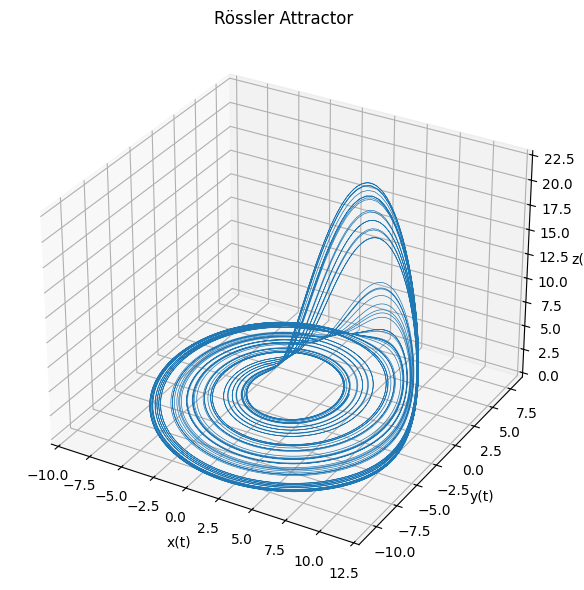

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Rössler parameters
a, b, c = 0.2, 0.2, 5.7

def rossler(X):
    x, y, z = X
    return np.array([
        -y - z,
        x + a*y,
        b + z*(x - c)
    ])

# Fast RK4 integrator
def rk4_step(X, h):
    k1 = rossler(X)
    k2 = rossler(X + 0.5*h*k1)
    k3 = rossler(X + 0.5*h*k2)
    k4 = rossler(X + h*k3)
    return X + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

# Settings
N = 15000
h = 0.025
X = np.array([1.0, 1.0, 1.0])

trajectory = np.empty((N, 3))

for i in range(N):
    trajectory[i] = X
    X = rk4_step(X, h)

# Remove initial transient
trajectory = trajectory[1500:]

x = trajectory[:, 0]
y = trajectory[:, 1]
z = trajectory[:, 2]

# Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot(x, y, z, linewidth=0.5)

ax.set_title("Rössler Attractor")
ax.set_xlabel("x(t)")
ax.set_ylabel("y(t)")
ax.set_zlabel("z(t)")

plt.tight_layout()
plt.show()

# **Visualization Methodology**

## **Visualization of the Rössler Attractor**

After removing the transient part, the coordinate arrays are extracted:

$$
x_n,\qquad y_n,\qquad z_n.
$$

The visualization plots the parametric curve $n\mapsto (x_n,y_n,z_n)\in \mathbb{R}^3.$ Equivalently, it approximates the continuous phase-space trajectory $t\mapsto (x(t),y(t),z(t)).$ For the chosen parameters $a=0.2, b=0.2, c=5.7,$ the plotted trajectory reveals the characteristic R\"ossler attractor. The orbit remains bounded but does not settle into a fixed point or simple periodic cycle. Instead, it exhibits the spiralling and folding structure associated with chaotic dynamics.

## **Downsampling for Efficient Rendering**

To reduce computational overhead during visualization, the trajectory is downsampled: $\tilde{\Gamma}_h = \{\mathbf{X}_{3k}\}.$ This corresponds to selecting every third point: $(x_{3k}, y_{3k}, z_{3k}).$ Downsampling reduces rendering complexity while preserving the geometric structure of the attractor, since nearby points in phase space are strongly correlated.

## **Polyline Approximation of the Orbit**

The attractor is visualized as a continuous curve by connecting consecutive sampled points:

$$
\tilde{\Gamma}_h \approx \bigcup_{k} [\mathbf{X}_{3k}, \mathbf{X}_{3(k+1)}].
$$

This produces a piecewise linear approximation of the trajectory.

In [9]:
import numpy as np
import plotly.graph_objects as go

# Rössler parameters
a, b, c = 0.2, 0.2, 5.7

def rossler(X):
    x, y, z = X
    return np.array([
        -y - z,
        x + a*y,
        b + z*(x - c)
    ])

def rk4_step(X, h):
    k1 = rossler(X)
    k2 = rossler(X + 0.5*h*k1)
    k3 = rossler(X + 0.5*h*k2)
    k4 = rossler(X + h*k3)
    return X + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

# Fast settings
h = 0.03
N = 25000
X = np.array([1.0, 1.0, 1.0])

trajectory = np.empty((N, 3))

for i in range(N):
    trajectory[i] = X
    X = rk4_step(X, h)

# Remove transient
trajectory = trajectory[1500:]

# Downsample for Plotly speed
trajectory = trajectory[::3]

x = trajectory[:, 0]
y = trajectory[:, 1]
z = trajectory[:, 2]

fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=x,
        y=y,
        z=z,
        mode="lines",
        line=dict(width=3),
        name="Rössler Attractor"
    )
)

fig.update_layout(
    title="Rössler Attractor",
    scene=dict(
        xaxis_title="x(t)",
        yaxis_title="y(t)",
        zaxis_title="z(t)"
    ),
    width=900,
    height=700
)

fig.show()

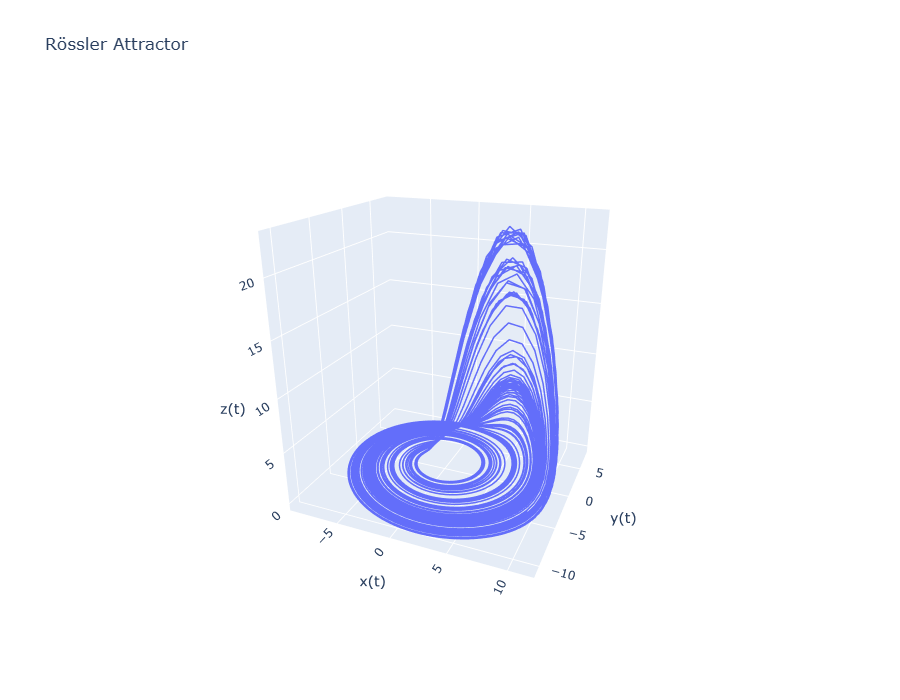

## **Three-Dimensional Rendering**

The visualization is implemented using a 3D plotting framework, where the coordinate arrays $\{x_n\},\{y_n\}, \{z_n\}$ are mapped to a spatial curve.
Thus, the numerical data is interpreted as $ (x_n, y_n, z_n) \in \mathbb{R}^3,$
forming a trajectory in phase space. The resulting graphical object represents the evolution of the system $\mathbf{X}_n \mapsto \Gamma_h.$

## **Geometric Interpretation of the Visualization**

The rendered curve exhibits characteristic features of the Rössler attractor:

- Spiralling motion around an unstable region,
- repeated stretching and folding of trajectories,
- bounded yet non-periodic evolution,
- dense filling of a subset of phase space.

These features arise from the nonlinear interaction term $z(x-c)$, which induces coupling between the components and leads to complex geometric structure.

## **Computational Visualization Pipeline**

The full computational and visualization procedure may be summarized as the following pipeline:

$$
\text{Rössler vector field}
\;\longrightarrow\;
\text{RK4 time-stepping}
\;\longrightarrow\;
\text{discrete orbit}
\;\longrightarrow\;
\text{transient removal}
\;\longrightarrow\;
\text{downsampling}
\;\longrightarrow\;
\text{polyline construction}
\;\longrightarrow\;
\text{3D phase-space visualization}.
$$

Symbolically, this can be written as

$$
\dot{\mathbf{X}}=F(\mathbf{X})
\;\longrightarrow\;
\{\mathbf{X}_n\}_{n=0}^{N-1}
\;\longrightarrow\;
\{\mathbf{X}_n\}_{n=1500}^{N-1}
\;\longrightarrow\;
\{\mathbf{X}_{1500+3k}\}_{k\geq 0}
\;\longrightarrow\;
\widetilde{\Gamma}_h
\;\longrightarrow\;
\widetilde{\Gamma}_h\subset\mathbb{R}^3.
$$

Here,

$$
\widetilde{\Gamma}_h
\approx
\bigcup_{k}
[\mathbf{X}_{1500+3k},\mathbf{X}_{1500+3(k+1)}],
$$

is the downsampled polyline approximation of the Rössler attractor. Thus, the computation transforms the nonlinear differential system into a discrete geometric object in phase space:

$$
\dot{\mathbf{X}}=F(\mathbf{X})
\quad\leadsto\quad
\widetilde{\Gamma}_h\subset\mathbb{R}^3.
$$



# **Conclusion**
The final plot is not merely a graph of functions, but a representation of a dynamical invariant set: $\Gamma_h \approx \mathcal{A},$ where $\mathcal{A}$ denotes the Rössler attractor. Thus, the visualization transforms numerical data into a geometric object that captures the qualitative behaviour of the dynamical system. The Rössler attractor serves as an archetypal example of how nonlinear interactions produce rich dynamical behaviour. By combining rigorous mathematical structure with carefully designed computational visualization, one obtains a deeper understanding of both local and global dynamics.
